A centroid (bottom=0.00, top=0.30): x=2.0730, y=0.1459
B centroid (bottom=0.00, top=1.00): x=4.2222, y=0.4444
A+B centroid (A:0-0.30000000000000004, B:0-1): x=3.6418, y=0.3638
A centroid (bottom=0.00, top=0.10): x=2.0248, y=0.0496
A+B centroid (A:0-0.1, B:0-0): x=2.0248, y=0.0496
A centroid (bottom=0.00, top=1.73): x=2.3226, y=0.6453
B centroid (bottom=0.00, top=2.00): x=4.3333, y=0.6667
A+B centroid (A:0-1.73, B:0-2): x=3.3372, y=0.6561
B centroid (bottom=0.00, top=2.00): x=4.3333, y=0.6667
A+B centroid (A:0-0, B:0-2): x=4.3333, y=0.6667


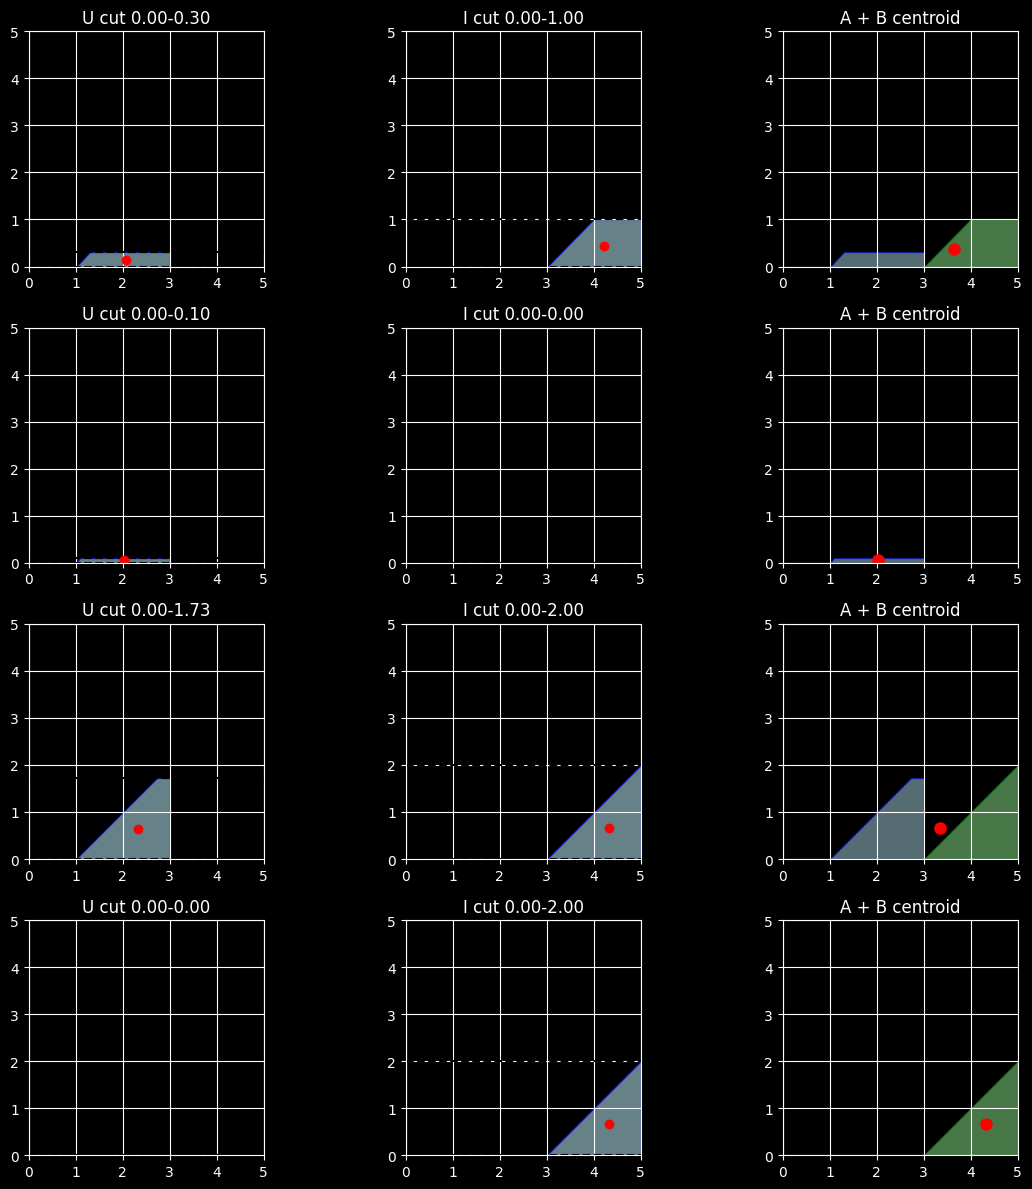

In [44]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from shapely.geometry import Polygon as ShapelyPolygon
from shapely.ops import unary_union

# Iн 1 -  Im - 5
# Uн - 1 U - 2


# ==============================
# ТРЕУГОЛЬНИКИ
# ==============================
triangleA = [[1,0],[3,2],[3,0]]
triangleB = [[3,0],[5,2],[5,0]]

# ==============================
# ЯВНЫЕ ВЕРХНИЕ И НИЖНИЕ СРЕЗЫ
# ==============================
bottom_cuts_A = [0, 0, 0, 0]
top_cuts_A    = [0.1 * 3, 0.1, 1.73, 0]

bottom_cuts_B = [0, 0, 0, 0]
top_cuts_B    = [1, 0, 2, 2]

# ==============================
# ГЕОМЕТРИЯ
# ==============================
def slice_band(triangle, bottom, top):
    """Создаёт полосу треугольника между bottom и top с правильным обходом"""
    intersections_bottom = []
    intersections_top = []
    inside = []

    # ищем точки на сторонах
    for i in range(3):
        p1, p2 = triangle[i], triangle[(i+1)%3]

        # точки внутри диапазона
        if bottom <= p1[1] <= top:
            inside.append(p1)

        # пересечение с bottom
        if (p1[1] - bottom)*(p2[1]-bottom) < 0:
            t = (bottom - p1[1])/(p2[1]-p1[1])
            x = p1[0] + t*(p2[0]-p1[0])
            intersections_bottom.append([x, bottom])

        # пересечение с top
        if (p1[1] - top)*(p2[1]-top) < 0:
            t = (top - p1[1])/(p2[1]-p1[1])
            x = p1[0] + t*(p2[0]-p1[0])
            intersections_top.append([x, top])

    # строим обход: снизу слева направо, сверху справа налево
    bottom_line = sorted(intersections_bottom + [p for p in inside if p[1]==bottom], key=lambda p: p[0])
    top_line    = sorted(intersections_top + [p for p in inside if p[1]==top], key=lambda p: -p[0])

    middle_points = [p for p in inside if bottom < p[1] < top]

    band = bottom_line + middle_points + top_line
    # удаляем дубликаты
    band_unique = []
    for p in band:
        if p not in band_unique:
            band_unique.append(p)
    return band_unique

def centroid(points):
    if len(points) < 3: return None
    poly = ShapelyPolygon(points)
    if poly.is_valid: return [poly.centroid.x, poly.centroid.y]
    return None

def combined_centroid(polys):
    shapes = []
    for p in polys:
        if len(p) >= 3:
            poly = ShapelyPolygon(p)
            if poly.is_valid: shapes.append(poly)
    if not shapes: return None
    comb = unary_union(shapes)
    return [comb.centroid.x, comb.centroid.y]

# ==============================
# РИСОВАНИЕ
# ==============================
def draw_triangle(ax, triangle, bottom, top, name="A"):
    band = slice_band(triangle, bottom, top)
    tri = Polygon(triangle, edgecolor='black', facecolor='none', linewidth=2)
    ax.add_patch(tri)
    ax.axhline(bottom, color='k', linestyle='--')
    ax.axhline(top, color='k', linestyle='--')
    c = None
    if len(band) >= 3:
        poly = Polygon(band, edgecolor='blue', facecolor='lightblue', alpha=0.6)
        ax.add_patch(poly)
        c = centroid(band)
        if c: ax.plot(c[0], c[1], 'ro', markersize=6)
    if c:
        print(f"{name} centroid (bottom={bottom:.2f}, top={top:.2f}): x={c[0]:.4f}, y={c[1]:.4f}")
    return band

def draw_combined(ax, tA, tB, bA, tA_, bB, tB_):
    bandA = slice_band(tA, bA, tA_)
    bandB = slice_band(tB, bB, tB_)
    if len(bandA) >= 3: ax.add_patch(Polygon(bandA, edgecolor='blue', facecolor='lightblue', alpha=0.5))
    if len(bandB) >= 3: ax.add_patch(Polygon(bandB, edgecolor='green', facecolor='lightgreen', alpha=0.5))
    c = combined_centroid([bandA, bandB])
    if c:
        ax.plot(c[0], c[1], 'ro', markersize=8)
        print(f"A+B centroid (A:{bA}-{tA_}, B:{bB}-{tB_}): x={c[0]:.4f}, y={c[1]:.4f}")

# ==============================
# MAIN
# ==============================
def main():
    fig, axes = plt.subplots(4,3,figsize=(12,12))
    for i in range(4):
        axA, axB, axAB = axes[i]
        draw_triangle(axA, triangleA, bottom_cuts_A[i], top_cuts_A[i], name="A")
        draw_triangle(axB, triangleB, bottom_cuts_B[i], top_cuts_B[i], name="B")
        draw_combined(axAB, triangleA, triangleB, bottom_cuts_A[i], top_cuts_A[i], bottom_cuts_B[i], top_cuts_B[i])
        for ax in [axA, axB, axAB]:
            ax.set_xlim(0,5)
            ax.set_ylim(0,5)
            ax.set_aspect('equal')
            ax.grid(True)
        axA.set_title(f"U cut {bottom_cuts_A[i]:.2f}-{top_cuts_A[i]:.2f}")
        axB.set_title(f"I cut {bottom_cuts_B[i]:.2f}-{top_cuts_B[i]:.2f}")
        axAB.set_title("A + B centroid")
    plt.tight_layout()
    plt.show()

if __name__=="__main__":
    main()

A centroid (bottom=0.00, top=0.30): x=2.0730, y=0.1459
B centroid (bottom=0.00, top=1.00): x=4.2222, y=0.4444
A+B centroid (A:0-0.3, B:0-1): x=3.6418, y=0.3638
A centroid (bottom=0.00, top=0.10): x=2.0248, y=0.0496
A+B centroid (A:0-0.1, B:0-0): x=2.0248, y=0.0496
A centroid (bottom=0.00, top=1.73): x=2.3226, y=0.6453
B centroid (bottom=0.00, top=2.00): x=4.3333, y=0.6667
A+B centroid (A:0-1.73, B:0-2): x=3.3372, y=0.6561
B centroid (bottom=0.00, top=2.00): x=4.3333, y=0.6667
A+B centroid (A:0-0, B:0-2): x=4.3333, y=0.6667


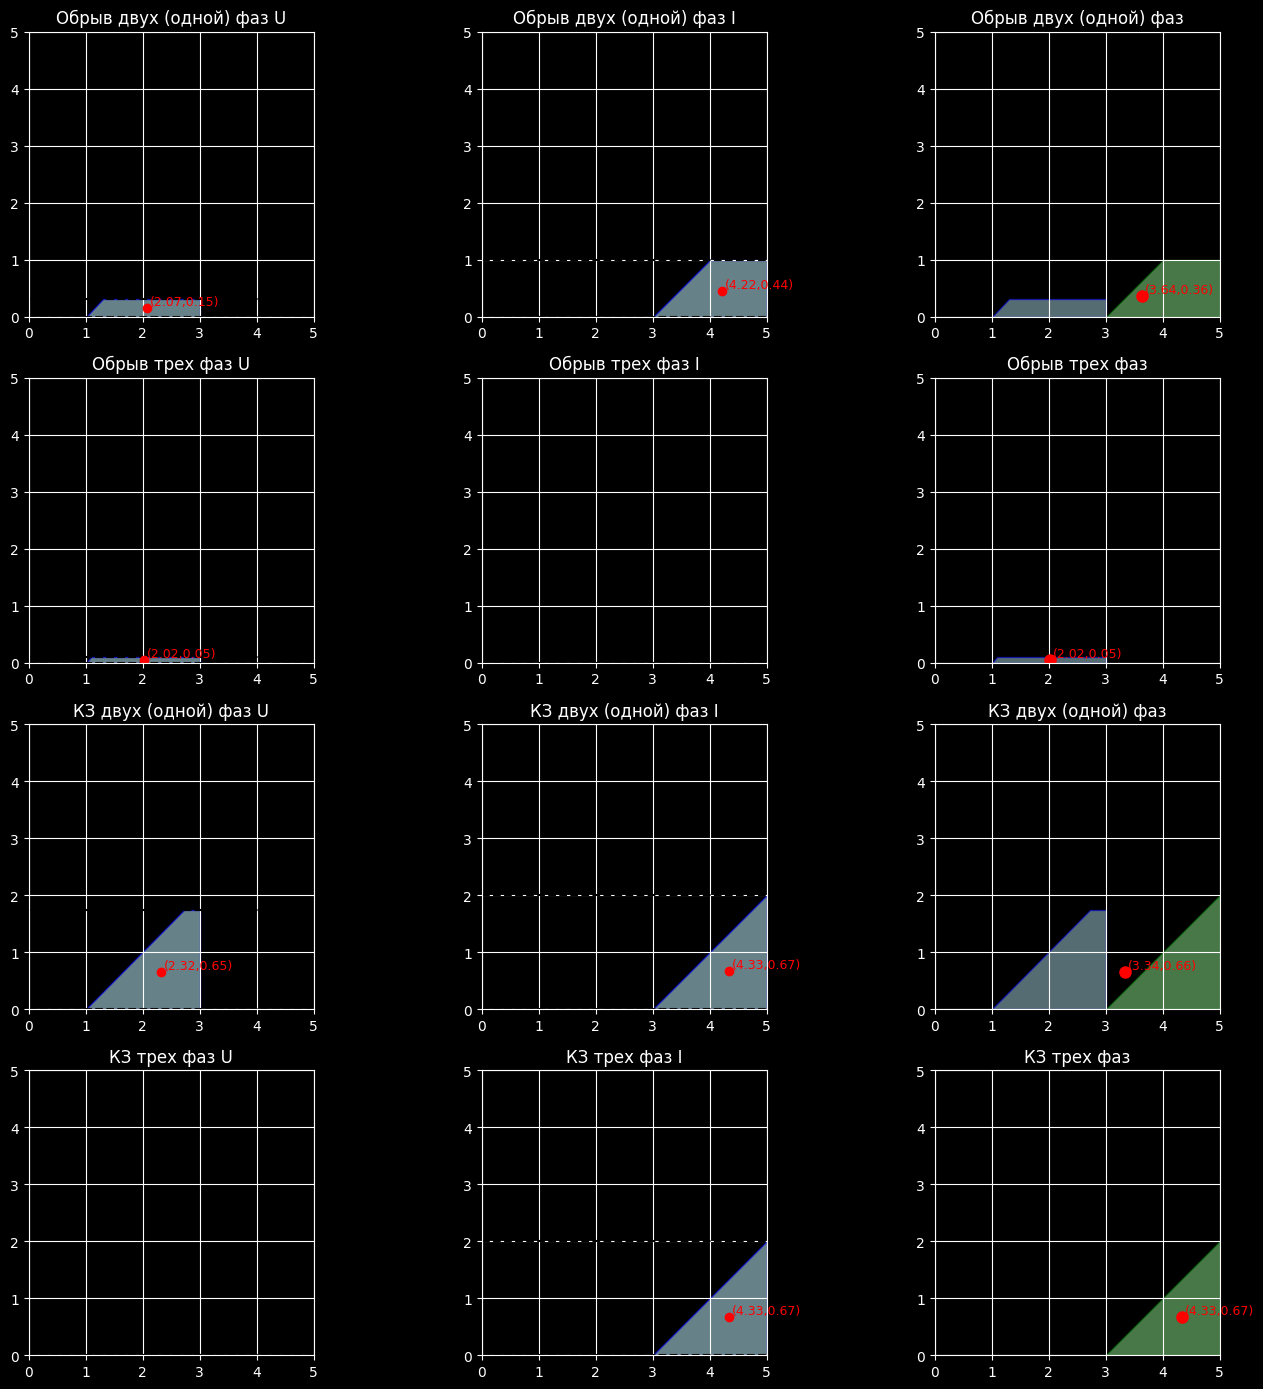

In [45]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from shapely.geometry import Polygon as ShapelyPolygon
from shapely.ops import unary_union

# ==============================
# ТРЕУГОЛЬНИКИ
# ==============================
triangleA = [[1,0],[3,2],[3,0]]
triangleB = [[3,0],[5,2],[5,0]]

# ==============================
# ЯВНЫЕ ВЕРХНИЕ И НИЖНИЕ СРЕЗЫ
# ==============================
bottom_cuts_A = [0, 0, 0, 0]
top_cuts_A    = [0.3, 0.1, 1.73, 0]

bottom_cuts_B = [0, 0, 0, 0]
top_cuts_B    = [1, 0, 2, 2]

# ==============================
# ГЕОМЕТРИЯ
# ==============================
def slice_band(triangle, bottom, top):
    intersections_bottom = []
    intersections_top = []
    inside = []

    for i in range(3):
        p1, p2 = triangle[i], triangle[(i+1)%3]

        if bottom <= p1[1] <= top:
            inside.append(p1)

        if (p1[1] - bottom)*(p2[1]-bottom) < 0:
            t = (bottom - p1[1])/(p2[1]-p1[1])
            x = p1[0] + t*(p2[0]-p1[0])
            intersections_bottom.append([x, bottom])

        if (p1[1] - top)*(p2[1]-top) < 0:
            t = (top - p1[1])/(p2[1]-p1[1])
            x = p1[0] + t*(p2[0]-p1[0])
            intersections_top.append([x, top])

    bottom_line = sorted(intersections_bottom + [p for p in inside if p[1]==bottom], key=lambda p: p[0])
    top_line    = sorted(intersections_top + [p for p in inside if p[1]==top], key=lambda p: -p[0])
    middle_points = [p for p in inside if bottom < p[1] < top]

    band = bottom_line + middle_points + top_line
    band_unique = []
    for p in band:
        if p not in band_unique:
            band_unique.append(p)
    return band_unique

def centroid(points):
    if len(points) < 3: return None
    poly = ShapelyPolygon(points)
    if poly.is_valid: return [poly.centroid.x, poly.centroid.y]
    return None

def combined_centroid(polys):
    shapes = []
    for p in polys:
        if len(p) >= 3:
            poly = ShapelyPolygon(p)
            if poly.is_valid: shapes.append(poly)
    if not shapes: return None
    comb = unary_union(shapes)
    return [comb.centroid.x, comb.centroid.y]

# ==============================
# РИСОВАНИЕ
# ==============================
def draw_triangle(ax, triangle, bottom, top, name="A"):
    band = slice_band(triangle, bottom, top)
    tri = Polygon(triangle, edgecolor='black', facecolor='none', linewidth=2)
    ax.add_patch(tri)

    # горизонтальные линии и подписи
    ax.axhline(bottom, color='k', linestyle='--')
    ax.axhline(top, color='k', linestyle='--')
    if bottom in [1,2]:
        ax.text(0.1, bottom + 0.05, f"Y={bottom}", color='black', fontsize=10)
    if top in [1,2]:
        ax.text(0.1, top + 0.05, f"Y={top}", color='black', fontsize=10)

    c = None
    if len(band) >= 3:
        poly = Polygon(band, edgecolor='blue', facecolor='lightblue', alpha=0.6)
        ax.add_patch(poly)
        c = centroid(band)
        if c:
            ax.plot(c[0], c[1], 'ro', markersize=6)
            ax.text(c[0]+0.05, c[1]+0.05, f"({c[0]:.2f},{c[1]:.2f})", color='red', fontsize=9)
    if c:
        print(f"{name} centroid (bottom={bottom:.2f}, top={top:.2f}): x={c[0]:.4f}, y={c[1]:.4f}")
    return band

def draw_combined(ax, tA, tB, bA, tA_, bB, tB_):
    bandA = slice_band(tA, bA, tA_)
    bandB = slice_band(tB, bB, tB_)
    if len(bandA) >= 3: ax.add_patch(Polygon(bandA, edgecolor='blue', facecolor='lightblue', alpha=0.5))
    if len(bandB) >= 3: ax.add_patch(Polygon(bandB, edgecolor='green', facecolor='lightgreen', alpha=0.5))
    c = combined_centroid([bandA, bandB])
    if c:
        ax.plot(c[0], c[1], 'ro', markersize=8)
        ax.text(c[0]+0.05, c[1]+0.05, f"({c[0]:.2f},{c[1]:.2f})", color='red', fontsize=9)
        print(f"A+B centroid (A:{bA}-{tA_}, B:{bB}-{tB_}): x={c[0]:.4f}, y={c[1]:.4f}")

# ==============================
# MAIN
# ==============================
def main():
    # заголовки можно менять здесь
    titles_A = ["Обрыв двух (одной) фаз U", "Обрыв трех фаз U", "КЗ двух (одной) фаз U", "КЗ трех фаз U"]
    titles_B = ["Обрыв двух (одной) фаз I", "Обрыв трех фаз I", "КЗ двух (одной) фаз I", "КЗ трех фаз I"]
    titles_AB = ["Обрыв двух (одной) фаз", "Обрыв трех фаз", "КЗ двух (одной) фаз", "КЗ трех фаз"]

    fig, axes = plt.subplots(4,3,figsize=(14,14))
    for i in range(4):
        axA, axB, axAB = axes[i]
        draw_triangle(axA, triangleA, bottom_cuts_A[i], top_cuts_A[i], name="A")
        draw_triangle(axB, triangleB, bottom_cuts_B[i], top_cuts_B[i], name="B")
        draw_combined(axAB, triangleA, triangleB, bottom_cuts_A[i], top_cuts_A[i], bottom_cuts_B[i], top_cuts_B[i])

        for ax in [axA, axB, axAB]:
            ax.set_xlim(0,5)
            ax.set_ylim(0,5)
            ax.set_aspect('equal')
            ax.grid(True)

        axA.set_title(titles_A[i])
        axB.set_title(titles_B[i])
        axAB.set_title(titles_AB[i])

    plt.tight_layout()
    plt.show()

if __name__=="__main__":
    main()